# Which towers can share a channel?

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))
for _pkg in ('plotly', 'anywidget'):
    try: __import__(_pkg)
    except ImportError:
        import subprocess; subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', _pkg])
import deckwidgets as dw          # deck slides as live iframes (graph-stage Canvas 2D; three.js for the rest)
import towers as tw, channels as ch, widgets as wg, networkx as nx

/Users/thegupta/Desktop/qBraid/repos/true-corp-demo/.venv/lib/python3.12/site-packages/IPython/core/display.py:452: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



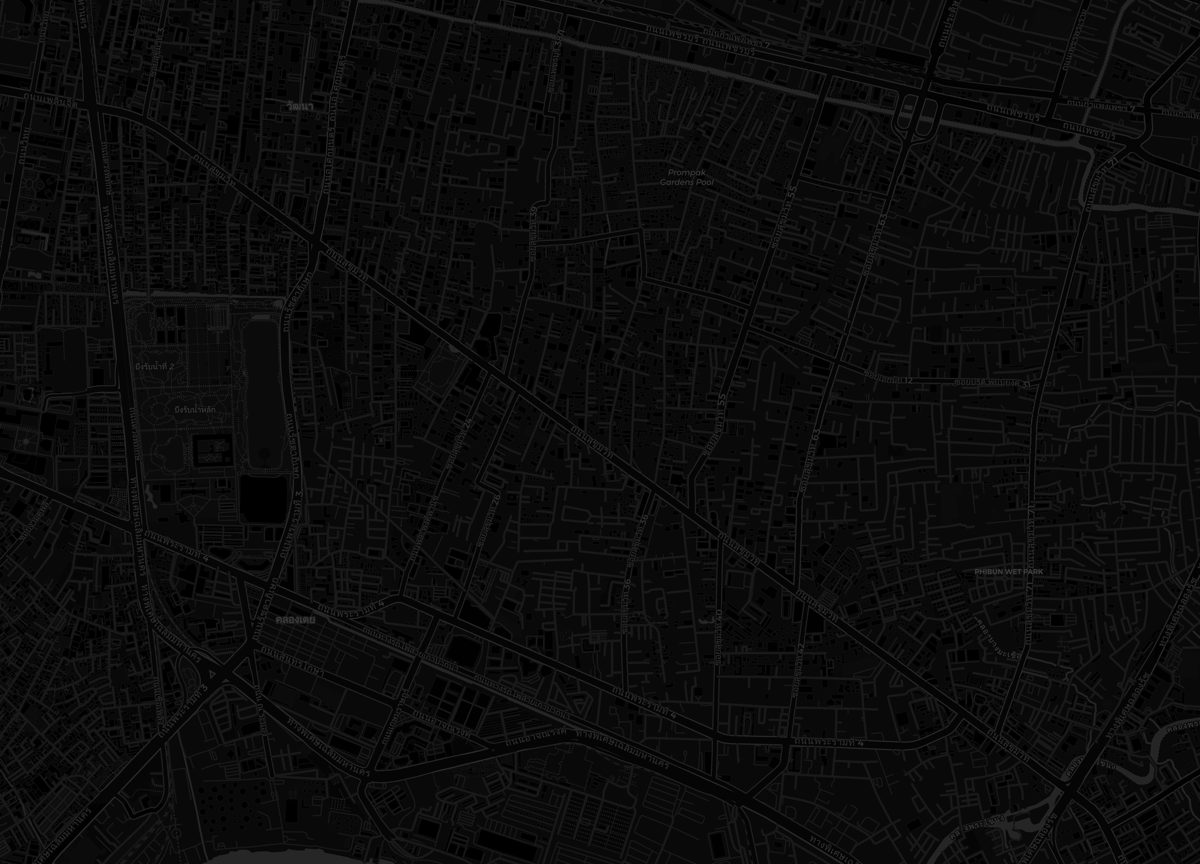
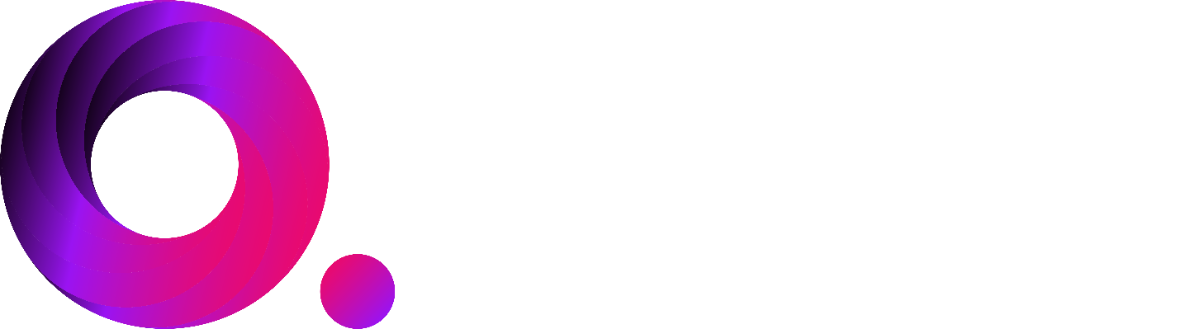
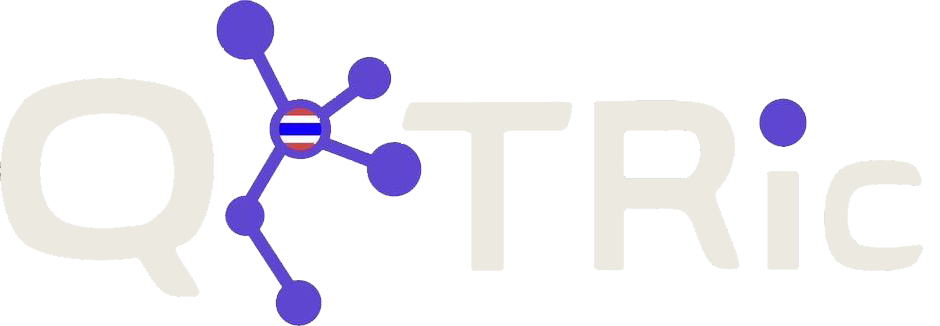

In [2]:
dw.deck_slide(0)


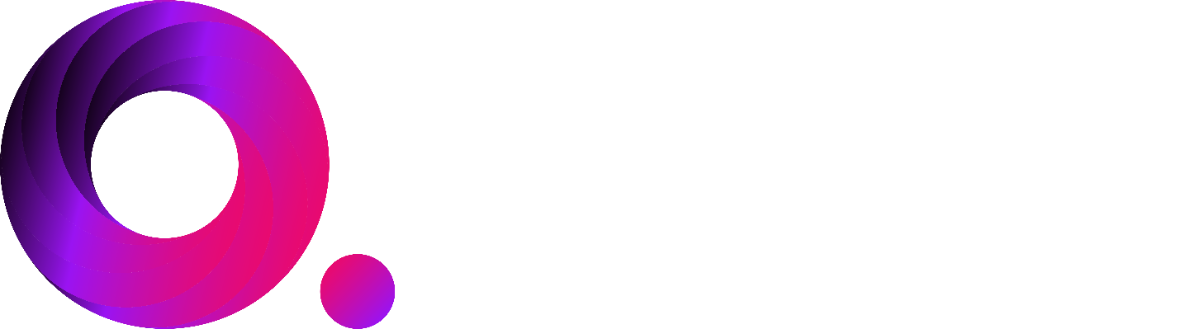

In [3]:
dw.deck_slide(1)


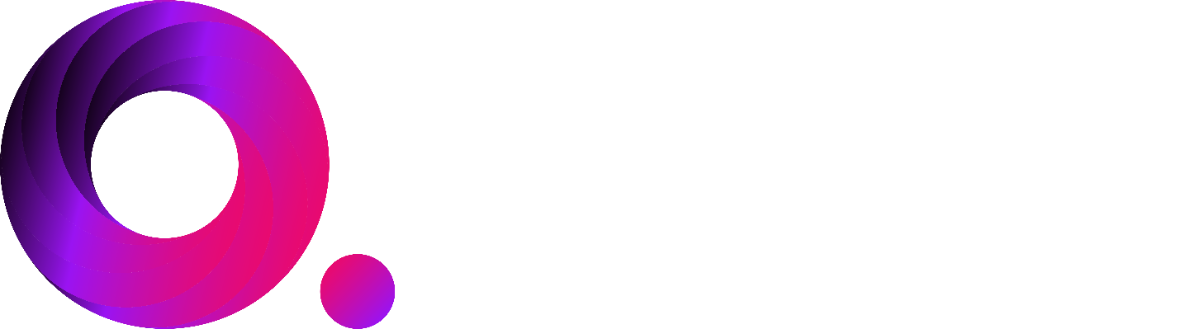

In [4]:
dw.deck_slide(2)


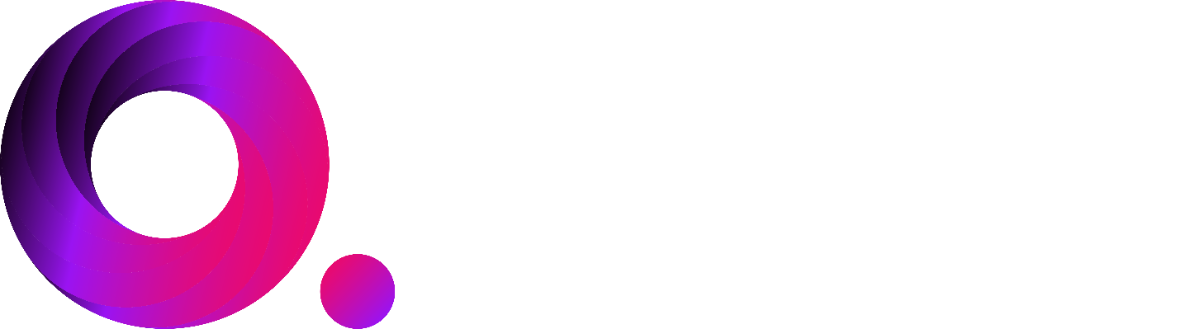
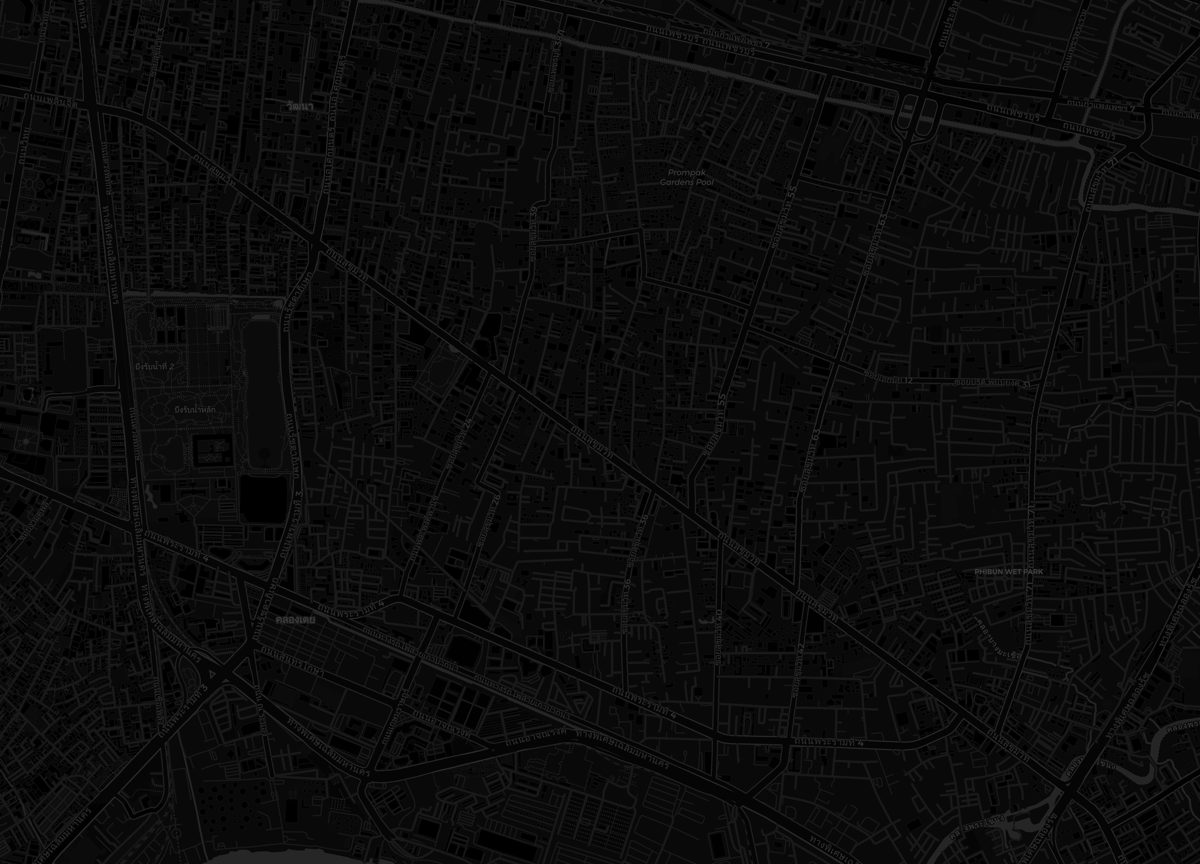

In [5]:
dw.deck_slide(3)


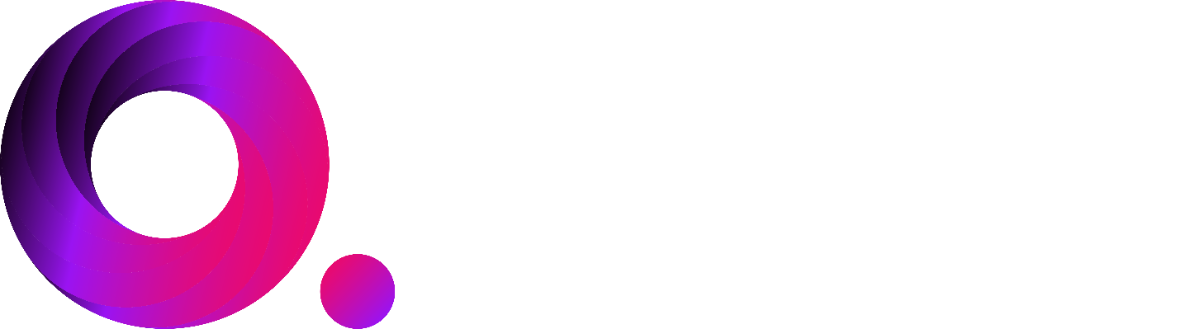

In [6]:
dw.deck_slide(4)

### Run it yourself: solve a random conflict graph on the AHS simulator, then colour it

In [7]:
# RUN IT YOURSELF: a random 12-tower conflict graph. Solve the largest co-channel
# group (a Maximum Independent Set) as an Analog Hamiltonian Simulation on the local
# braket_ahs simulator (no QPU), then finish the frequency plan by repeating the MIS.
from IPython.display import display

reg, G, xy = tw.random_conflict_graph(n=12)          # random unit-disk (blockade) graph
display(wg.graph_view(xy, list(G.edges())))          # 1. show the conflict graph

mis = tw.mis_on_simulator(reg, G, shots=200)         # 2. the MIS, measured on the simulator
channels, channel_of, _ = ch.iterated_mis_coloring(G, first_set=mis, solver="exact")
display(wg.channel_graph_view(xy, list(G.edges()), channels))   # 3. live colouring (drag the slider)

/Users/thegupta/Desktop/qBraid/repos/true-corp-demo/.venv/lib/python3.12/site-packages/IPython/core/display.py:452: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



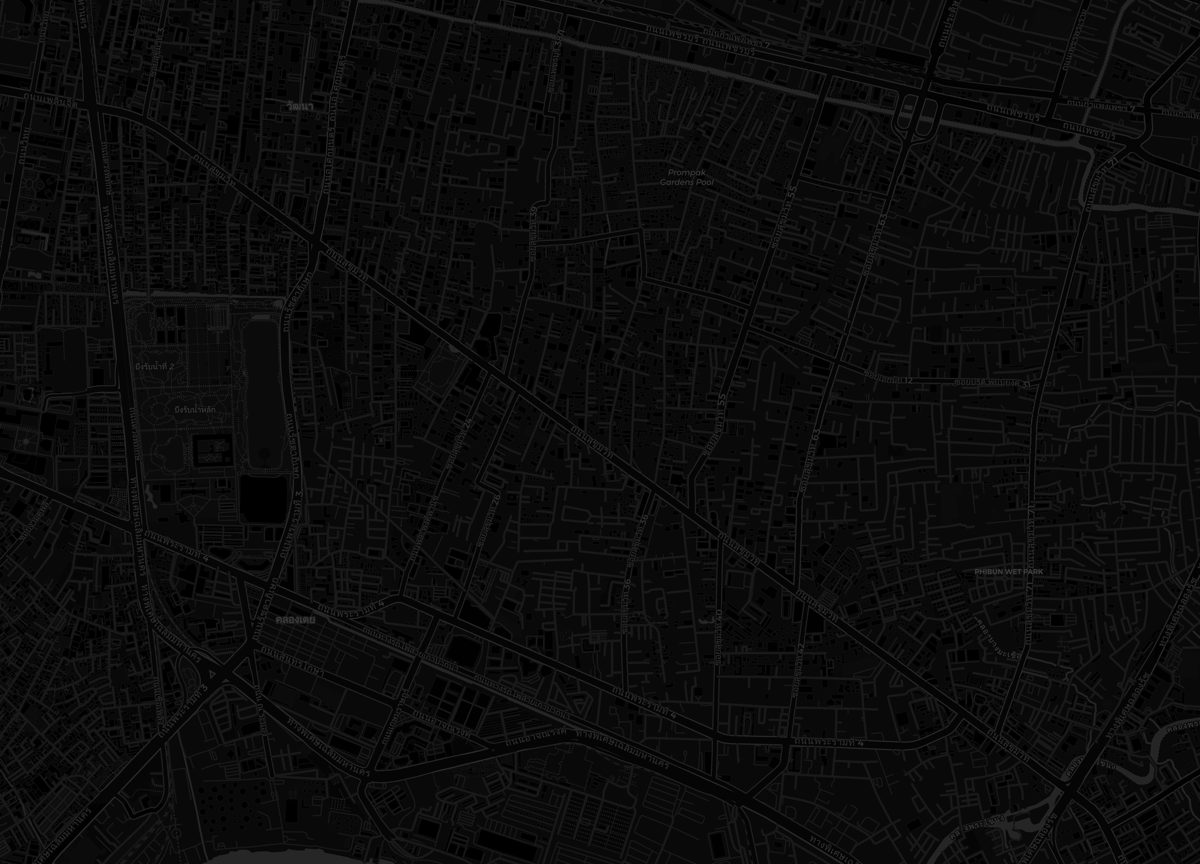
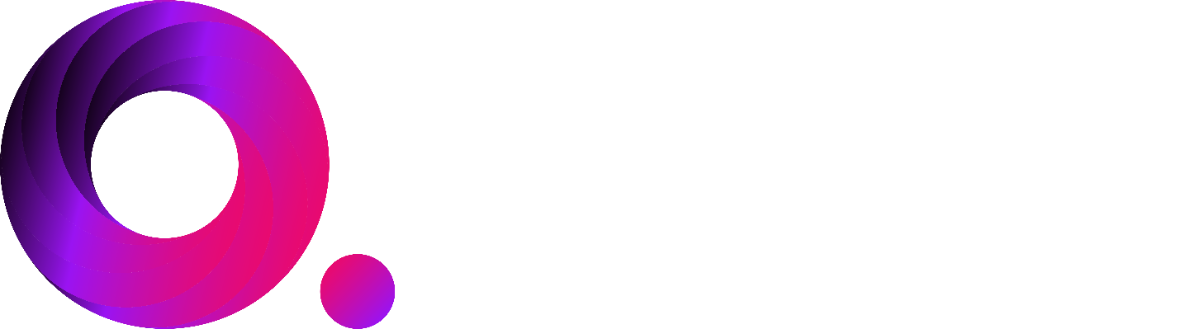

In [8]:
dw.deck_slide(5)


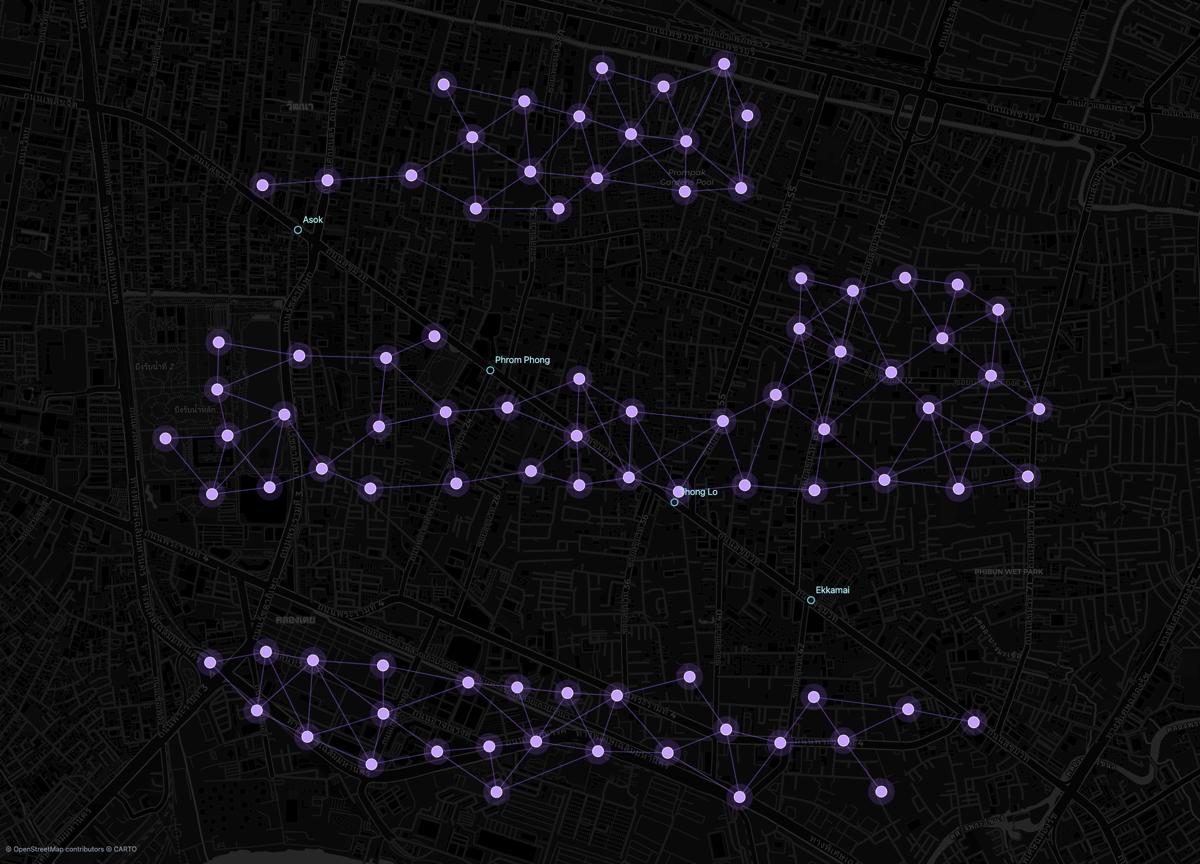
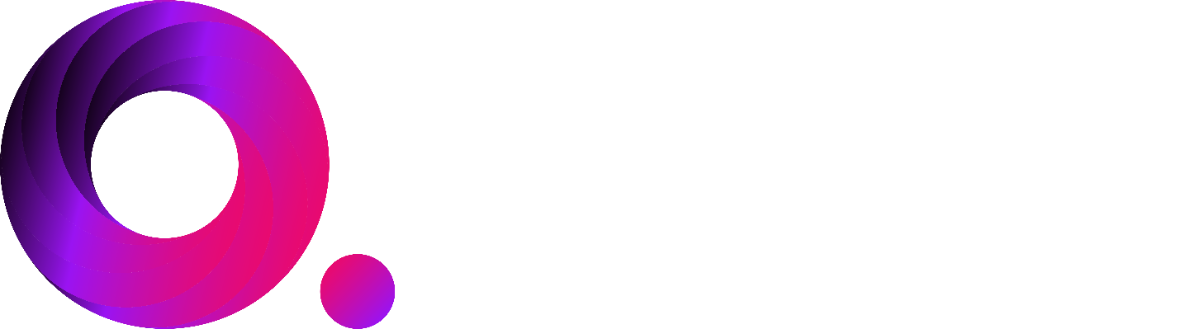

In [9]:
dw.deck_slide(6)


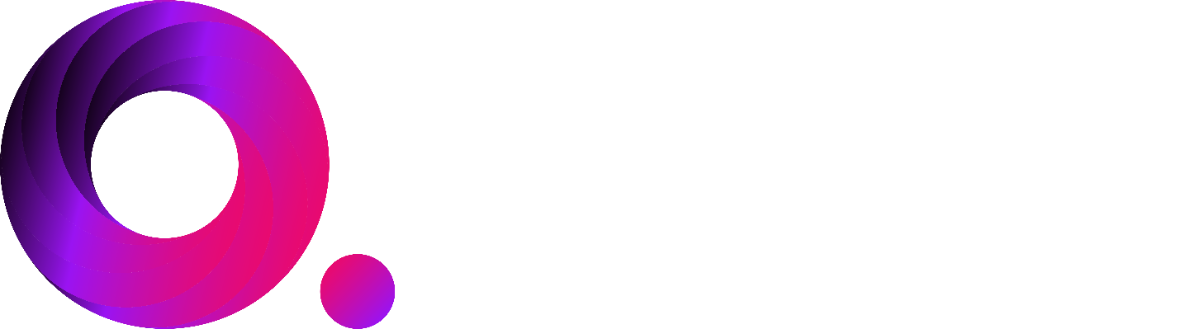
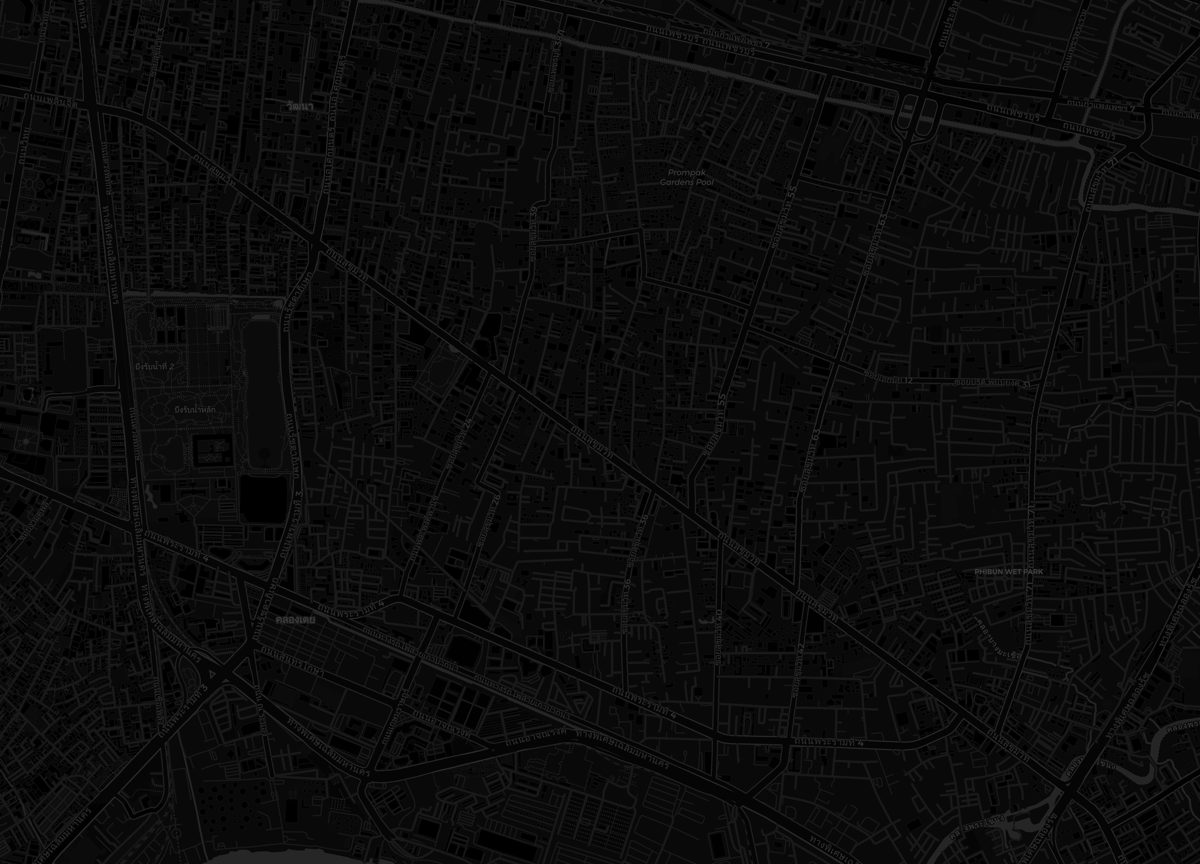

In [10]:
dw.deck_slide(7)


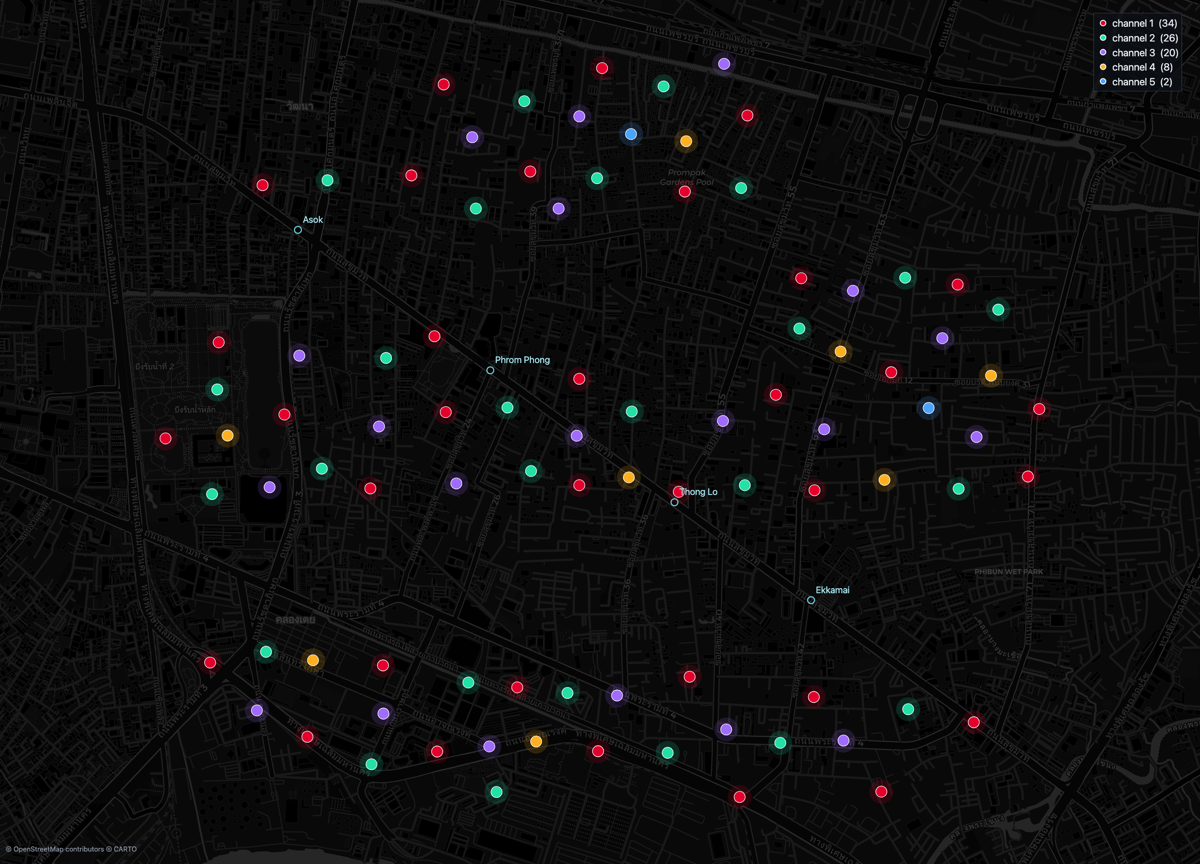
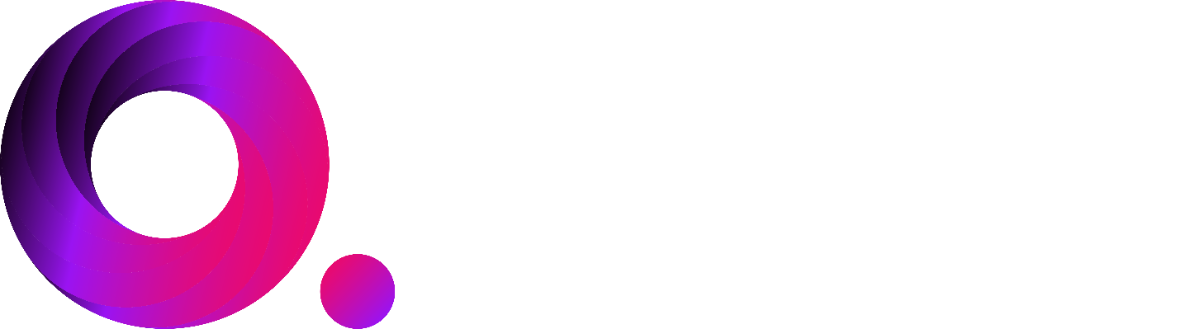

In [11]:
dw.deck_slide(8)

### The measured channel plan on the quantum system `Aquila` 

![QuEra Aquila on qBraid](resources/quera-device-image.png)

**How this plan was measured on Aquila.** Every channel is one Maximum Independent Set, solved on the QPU and then repeated on the towers left over. 

```python
# 1. EXTRACT: real OpenCelliD cells -> physical sites -> Aquila-legal atom register
df    = tw.load_cells("data/watthana_cells_real.csv")
cells = tw.filter_cells(df, bbox=WATTHANA)              # True-group LTE / UMTS
sites = tw.merge_close_sites(tw.cluster_cells_to_sites(cells, ref_lat, ref_lon))
reg   = tw.affine_to_atoms(sites)                       # scale + snap to the 4 um lattice
G     = tw.build_graph_from_register(reg)               # unit-disk = coverage-overlap graph

# 2. ENCODE: the MIS as a quasi-adiabatic Rydberg sweep (Analog Hamiltonian Simulation)
ahs = tw.build_ahs_program(reg)                         # Omega and Delta ramps; blockade = interference

# 3. SUBMIT: one AHS task to QuEra Aquila via qBraid (30 credits + 1 / shot)
from qbraid.runtime import QbraidProvider
device = QbraidProvider().get_device("aws:quera:qpu:aquila")
job    = device.run(ahs, shots=1000)                    # the only line that talks to the QPU

# 4. COLLECT + REPEAT: decode shots, reject blockade violations, keep the valid MIS,
#    then repeat on the leftover towers until every tower has a channel.
shots     = job.result().data.measurements
mis, _, _ = tw.best_valid_set(tw.decode_shots(shots, reg.n)[0], G)
channels  = ch.iterated_mis_coloring(G, first_set=mis)[0]
```

In [12]:
# THE MEASURED CHANNEL PLAN — the real Aquila runs (5 MIS rounds), validated.
import json
d = json.load(open('results/channel_assignment_90_qpu.json'))
print(f"source        : {d['source']}")
print(f"channels      : {d['n_channels']}   (optimal {d['chromatic_number']}, greedy overspend {d['overspend']})")
print(f"round sizes   : {d['round_sizes']}   towers per channel")
print(f"valid colouring: {d['valid']}  ·  90/90 towers, complete & disjoint")

source        : QPU_iterated
channels      : 5   (optimal 4, greedy overspend 1)
round sizes   : [34, 26, 20, 8, 2]   towers per channel
valid colouring: True  ·  90/90 towers, complete & disjoint



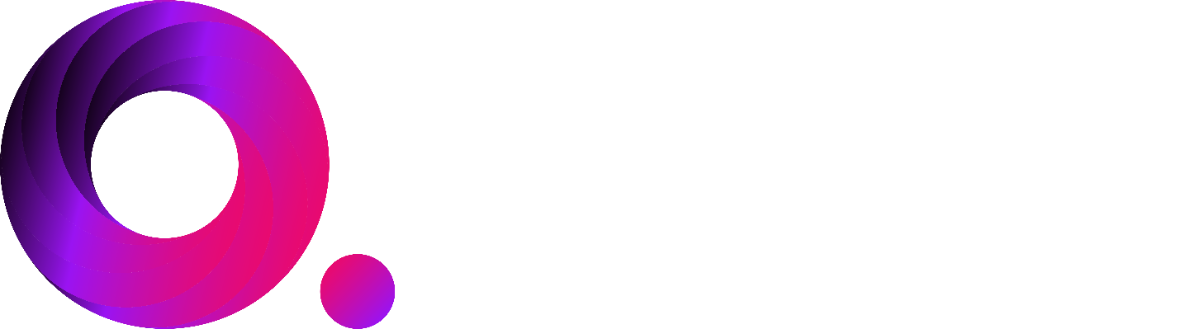

In [13]:
dw.deck_slide(9)


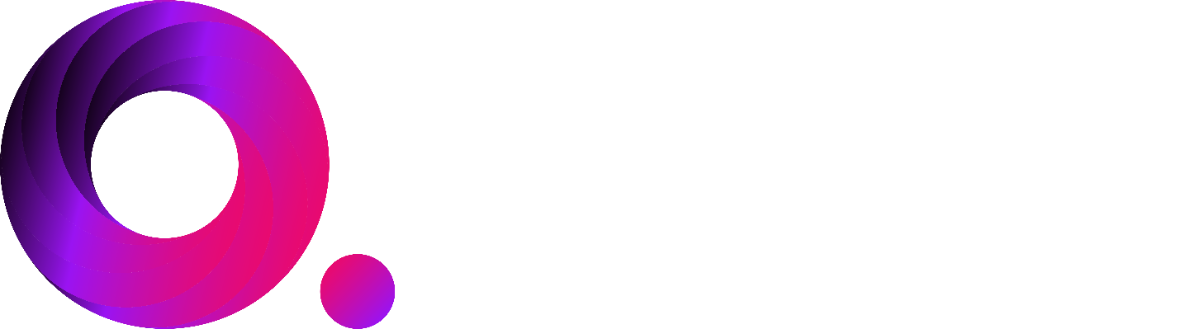

In [14]:
dw.deck_slide(10)

In [15]:
tw.print_assumptions()

ASSUMPTIONS  ·  Which towers can share a channel?
SCALE MAPPING (nothing tuned to flatter the hardware):
  coverage overlap           500 m   <-> blockade radius 8.4 um
  scale factor              59.5 m per um
  min site merge distance    238 m   <-> min atom spacing 4.0 um
  field of view             4.46 km  <-> 75.0 um (narrower than a human hair)
  -> 4.5 km of Sukhumvit, rendered in an area narrower than a hair. We did NOT
     tune the blockade radius to match; that is where rubidium happens to sit.
--------------------------------------------------------------------------
HONESTY CONSTRAINTS:
  * Protocol (unit-disk) model, not physical: conflicts are binary and pairwise,
    while real interference aggregates and fails on a threshold (SINR) ratio.
  * Coverage is modelled as UNIFORM-RADIUS disks. Real radii vary by band and tilt.
  * Positions are a REAL OpenCelliD extract (MCC 520, True-group MNCs): crowdsourced
    estimated centroids, NOT surveyed towers (data (c) OpenCelli